# Análise interativa - Solução 1 OpenCV

**Autor:** Manoel Furtado  
**Objetivo:** entender passo a passo a contagem de parafusos feita em `solucao_1_opencv_morfologia.py`.

Este notebook foi feito para estudo. Ele mostra as etapas intermediárias do pipeline:

1. carregar uma imagem;
2. converter para escala de cinza;
3. melhorar contraste com CLAHE;
4. gerar máscaras por threshold e bordas;
5. limpar máscaras com morfologia;
6. extrair contornos;
7. filtrar candidatos por área, formato e canto;
8. visualizar a imagem anotada.

A ideia é mudar os parâmetros manualmente e executar as células novamente para entender o efeito de cada ajuste.

## 1. Importações e caminhos

A célula abaixo importa bibliotecas e aponta para a pasta de imagens do Desafio 1. O notebook usa `matplotlib` para visualizar as imagens dentro do Jupyter.

In [2]:
import sys
from pathlib import Path
# Adiciona o subdiretorio da solucao ao path para importacao
sys.path.append(str(Path('.').resolve() / 'solucao_1_opencv_morfologia'))


import cv2
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path('../data/images')
IMAGE_PATHS = sorted(DATA_DIR.glob('*.jpg'))

print('Imagens encontradas:')
for i, path in enumerate(IMAGE_PATHS):
    print(i, path.name)

Imagens encontradas:
0 img1.jpg
1 img2.jpg
2 img3.jpg
3 img4.jpg
4 img5.jpg


## 2. Escolha da imagem

Troque `image_index` para testar outra imagem. A ordem é a mesma impressa na célula anterior.

Exemplos:

- `0` para `img1.jpg`;
- `1` para `img2.jpg`;
- `4` para `img5.jpg`.

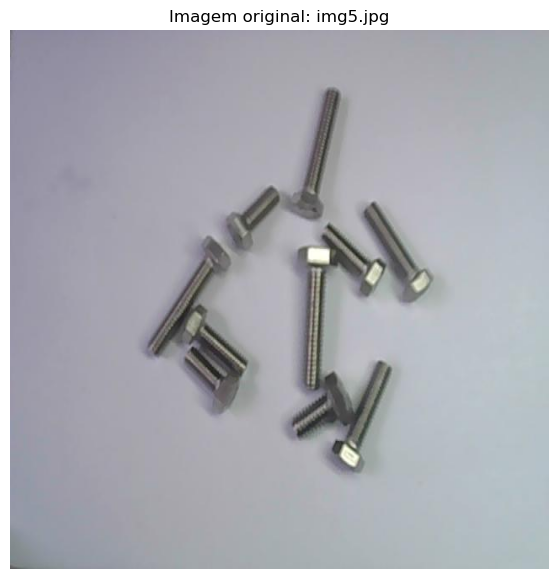

In [3]:
image_index = 4

image_path = IMAGE_PATHS[image_index]
image_bgr = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 7))
plt.imshow(image_rgb)
plt.title(f'Imagem original: {image_path.name}')
plt.axis('off');

## 3. Pré-processamento

O script começa convertendo a imagem para escala de cinza. Depois aplica **CLAHE**, uma técnica de equalização local de contraste. Isso ajuda porque algumas imagens têm iluminação irregular, sombras e reflexos.

Depois disso, aplicamos um blur para reduzir ruído pequeno antes do threshold.

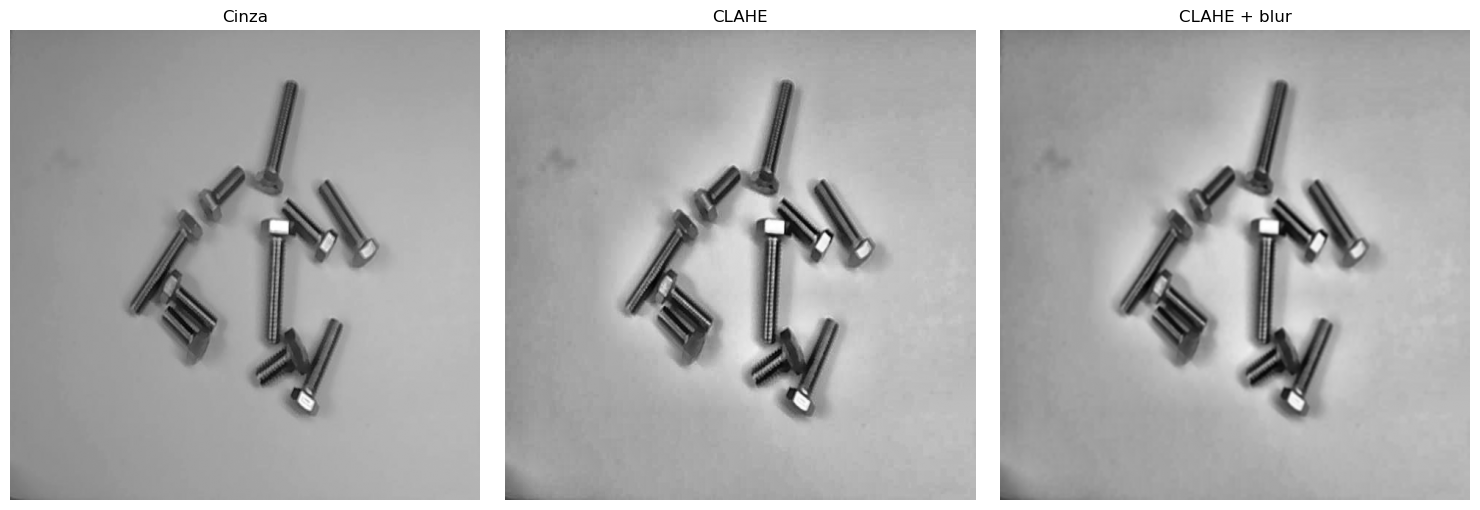

In [91]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

clahe_clip = 2.0
clahe_grid = (8, 8)
clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)
enhanced = clahe.apply(gray)

blur_kernel = (5, 5)
blurred = cv2.GaussianBlur(enhanced, blur_kernel, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in [
    (axes[0], gray, 'Cinza'),
    (axes[1], enhanced, 'CLAHE'),
    (axes[2], blurred, 'CLAHE + blur'),
]:
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout();

## 4. Máscaras automáticas

O script testa várias formas de segmentar os objetos:

- `otsu_dark`: tenta pegar objetos escuros em fundo claro;
- `otsu_light`: tenta pegar regiões claras/reflexos;
- `adaptive`: calcula limiar localmente, útil com iluminação irregular;
- `edges`: usa Canny para bordas.

Cada máscara é uma hipótese. Depois o algoritmo escolhe a que parece mais coerente.

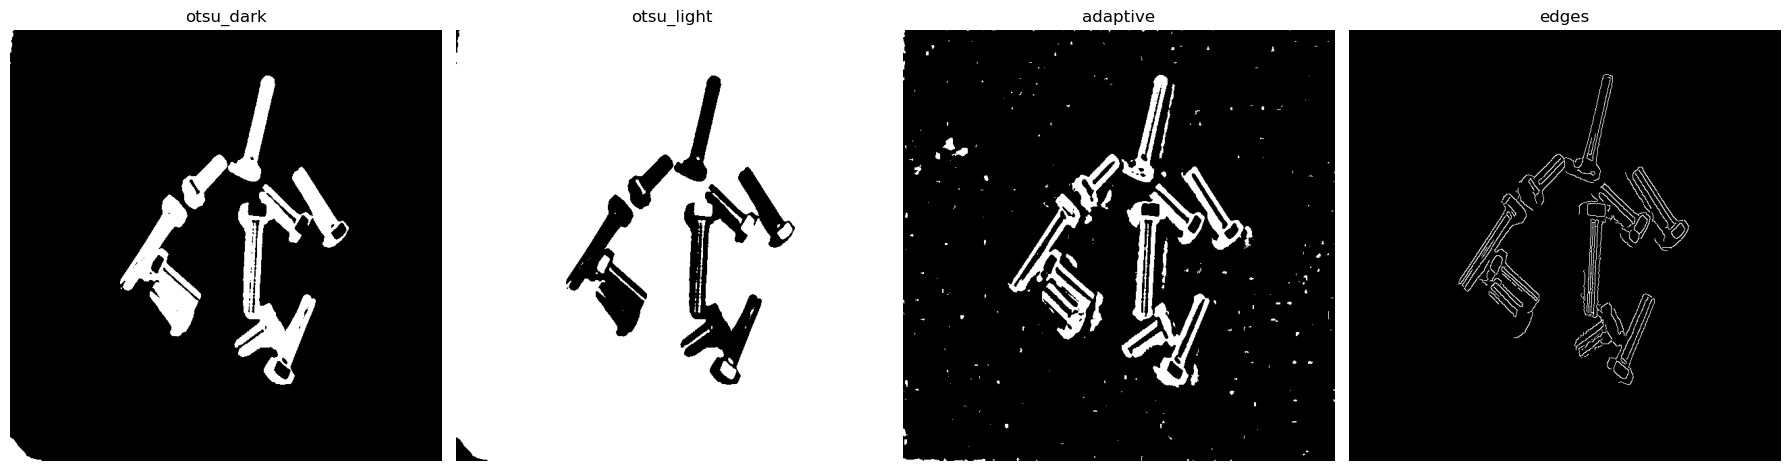

In [92]:
_, otsu_dark = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, otsu_light = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive_block_size = 41
adaptive_c = 4
adaptive = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    adaptive_block_size,
    adaptive_c,
)
edges = cv2.Canny(blurred, 60, 160)

raw_masks = {
    'otsu_dark': otsu_dark,
    'otsu_light': otsu_light,
    'adaptive': adaptive,
    'edges': edges,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, mask) in zip(axes, raw_masks.items()):
    ax.imshow(mask, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout();

## 5. Morfologia matemática

A morfologia limpa a máscara:

- **close** fecha pequenas falhas dentro do objeto;
- **open** remove pequenos ruídos isolados.

A ordem usada no script é close seguido de open.

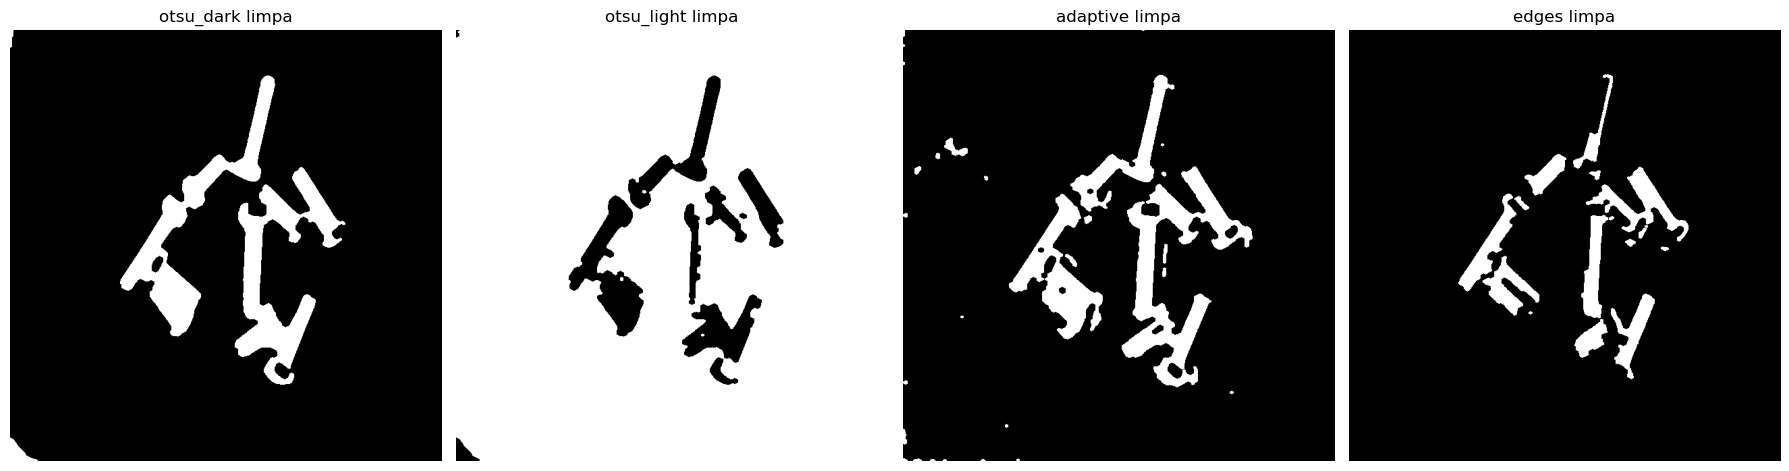

In [93]:
morph_kernel_size = 5
close_iterations = 2
open_iterations = 1

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
cleaned_masks = {}

for name, mask in raw_masks.items():
    cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=close_iterations)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel, iterations=open_iterations)
    cleaned_masks[name] = cleaned

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, mask) in zip(axes, cleaned_masks.items()):
    ax.imshow(mask, cmap='gray')
    ax.set_title(name + ' limpa')
    ax.axis('off')
plt.tight_layout();

## 6. Modo de limiar manual

Além do modo automático, o app tem o modo **Limiar manual**. Ele é útil quando o fundo é claro e os parafusos são escuros.

Ajuste `manual_threshold`. Valores menores pegam regiões mais escuras; valores maiores incluem mais pixels e podem juntar partes ou criar falsos positivos.

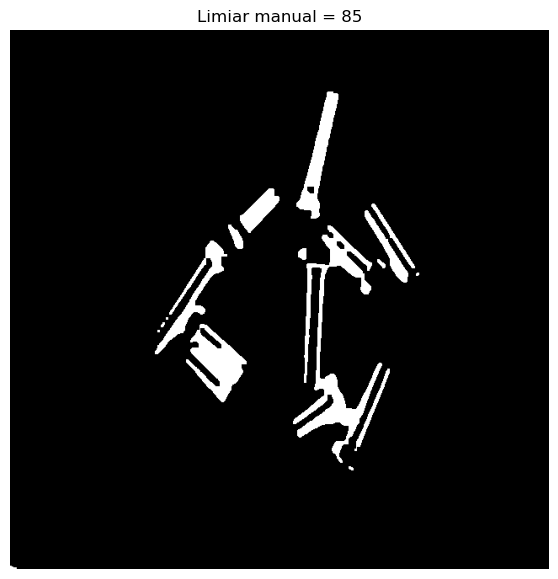

In [94]:
manual_threshold = 85
manual_blur = 'median'  # 'median' ou 'gauss'

manual_base = enhanced.copy()
if manual_blur == 'median':
    manual_filtered = cv2.medianBlur(manual_base, 5)
else:
    manual_filtered = cv2.GaussianBlur(manual_base, (5, 5), sigmaX=1.0)

_, manual_mask = cv2.threshold(manual_filtered, manual_threshold, 255, cv2.THRESH_BINARY_INV)
manual_mask = cv2.morphologyEx(manual_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
manual_mask = cv2.morphologyEx(manual_mask, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)

plt.figure(figsize=(7, 7))
plt.imshow(manual_mask, cmap='gray')
plt.title(f'Limiar manual = {manual_threshold}')
plt.axis('off');

## 7. Funções de filtro de contornos

Agora criamos funções parecidas com as do script. A lógica principal é:

1. encontrar contornos;
2. descartar áreas pequenas/grandes demais;
3. descartar formatos extremos;
4. descartar objetos colados em cantos;
5. manter candidatos plausíveis.

In [95]:
def touches_corner(x, y, w, h, image_width, image_height, margin):
    left = x <= margin
    top = y <= margin
    right = x + w >= image_width - margin
    bottom = y + h >= image_height - margin
    return (left and top) or (right and top) or (left and bottom) or (right and bottom)


def find_candidates(mask, min_area=80, max_area=20000, max_aspect_ratio=8.0, min_circularity=0.02, corner_margin=4):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    image_height, image_width = mask.shape[:2]
    candidates = []

    for contour in contours:
        area = float(cv2.contourArea(contour))
        if area < min_area or area > max_area:
            continue

        perimeter = float(cv2.arcLength(contour, True))
        if perimeter <= 0:
            continue

        x, y, w, h = cv2.boundingRect(contour)
        aspect_ratio = max(w / h, h / w)
        if aspect_ratio > max_aspect_ratio:
            continue

        circularity = float(4.0 * np.pi * area / (perimeter * perimeter))
        if circularity < min_circularity:
            continue

        if touches_corner(x, y, w, h, image_width, image_height, corner_margin):
            continue

        candidates.append({
            'x': x,
            'y': y,
            'w': w,
            'h': h,
            'area': area,
            'aspect_ratio': aspect_ratio,
            'circularity': circularity,
        })

    return sorted(candidates, key=lambda item: (item['y'], item['x']))

## 8. Teste de parâmetros em uma máscara

Escolha `mask_name` para avaliar uma máscara específica. Depois ajuste `min_area`, `max_area`, `expected_area` e `corner_margin`.

Dica: se aparecer muito ruído, aumente `min_area`. Se um parafuso grande sumir, aumente `max_area`.

In [96]:
mask_name = 'edges'  # 'otsu_dark', 'otsu_light', 'adaptive', 'edges' ou 'manual'

min_area = 80
max_area = 20000
max_aspect_ratio = 8.0
min_circularity = 0.02
corner_margin = 4

selected_mask = manual_mask if mask_name == 'manual' else cleaned_masks[mask_name]
candidates = find_candidates(
    selected_mask,
    min_area=min_area,
    max_area=max_area,
    max_aspect_ratio=max_aspect_ratio,
    min_circularity=min_circularity,
    corner_margin=corner_margin,
)

print(f'Máscara: {mask_name}')
print(f'Candidatos: {len(candidates)}')
for i, item in enumerate(candidates, start=1):
    print(i, item)

Máscara: edges
Candidatos: 12
1 {'x': 332, 'y': 67, 'w': 59, 'h': 140, 'area': 1270.5, 'aspect_ratio': 2.3728813559322033, 'circularity': 0.10988217682801815}
2 {'x': 260, 'y': 185, 'w': 62, 'h': 62, 'area': 1528.5, 'aspect_ratio': 1.0, 'circularity': 0.4865284900867239}
3 {'x': 351, 'y': 204, 'w': 152, 'h': 111, 'area': 4143.0, 'aspect_ratio': 1.3693693693693694, 'circularity': 0.0985724392123677}
4 {'x': 356, 'y': 209, 'w': 17, 'h': 15, 'area': 118.5, 'aspect_ratio': 1.1333333333333333, 'circularity': 0.5258833390721706}
5 {'x': 162, 'y': 244, 'w': 86, 'h': 145, 'area': 3016.0, 'aspect_ratio': 1.686046511627907, 'circularity': 0.2142833878555246}
6 {'x': 245, 'y': 247, 'w': 22, 'h': 22, 'area': 156.0, 'aspect_ratio': 1.0, 'circularity': 0.44427610164196313}
7 {'x': 344, 'y': 275, 'w': 40, 'h': 154, 'area': 2859.5, 'aspect_ratio': 3.85, 'circularity': 0.25833961964812646}
8 {'x': 429, 'y': 290, 'w': 14, 'h': 21, 'area': 100.0, 'aspect_ratio': 1.5, 'circularity': 0.40861587027730034}
9

In [97]:
mask_name = 'manual'  # 'otsu_dark', 'otsu_light', 'adaptive', 'edges' ou 'manual'

min_area = 500
max_area = 17500
max_aspect_ratio = 8.0
min_circularity = 0.02
corner_margin = 9

selected_mask = manual_mask if mask_name == 'manual' else cleaned_masks[mask_name]
candidates = find_candidates(
    selected_mask,
    min_area=min_area,
    max_area=max_area,
    max_aspect_ratio=max_aspect_ratio,
    min_circularity=min_circularity,
    corner_margin=corner_margin,
)

print(f'Máscara: {mask_name}')
print(f'Candidatos: {len(candidates)}')
for i, item in enumerate(candidates, start=1):
    print(i, item)

Máscara: manual
Candidatos: 6
1 {'x': 340, 'y': 73, 'w': 50, 'h': 151, 'area': 2318.5, 'aspect_ratio': 3.02, 'circularity': 0.2226717025403752}
2 {'x': 273, 'y': 188, 'w': 47, 'h': 53, 'area': 1056.5, 'aspect_ratio': 1.127659574468085, 'circularity': 0.5922472625783416}
3 {'x': 421, 'y': 214, 'w': 52, 'h': 86, 'area': 813.0, 'aspect_ratio': 1.6538461538461537, 'circularity': 0.2170885229371281}
4 {'x': 336, 'y': 232, 'w': 106, 'h': 282, 'area': 5406.0, 'aspect_ratio': 2.660377358490566, 'circularity': 0.027237407476441235}
5 {'x': 172, 'y': 250, 'w': 86, 'h': 135, 'area': 1837.0, 'aspect_ratio': 1.569767441860465, 'circularity': 0.07238441339500636}
6 {'x': 209, 'y': 349, 'w': 72, 'h': 93, 'area': 3056.0, 'aspect_ratio': 1.2916666666666667, 'circularity': 0.27352340592734714}


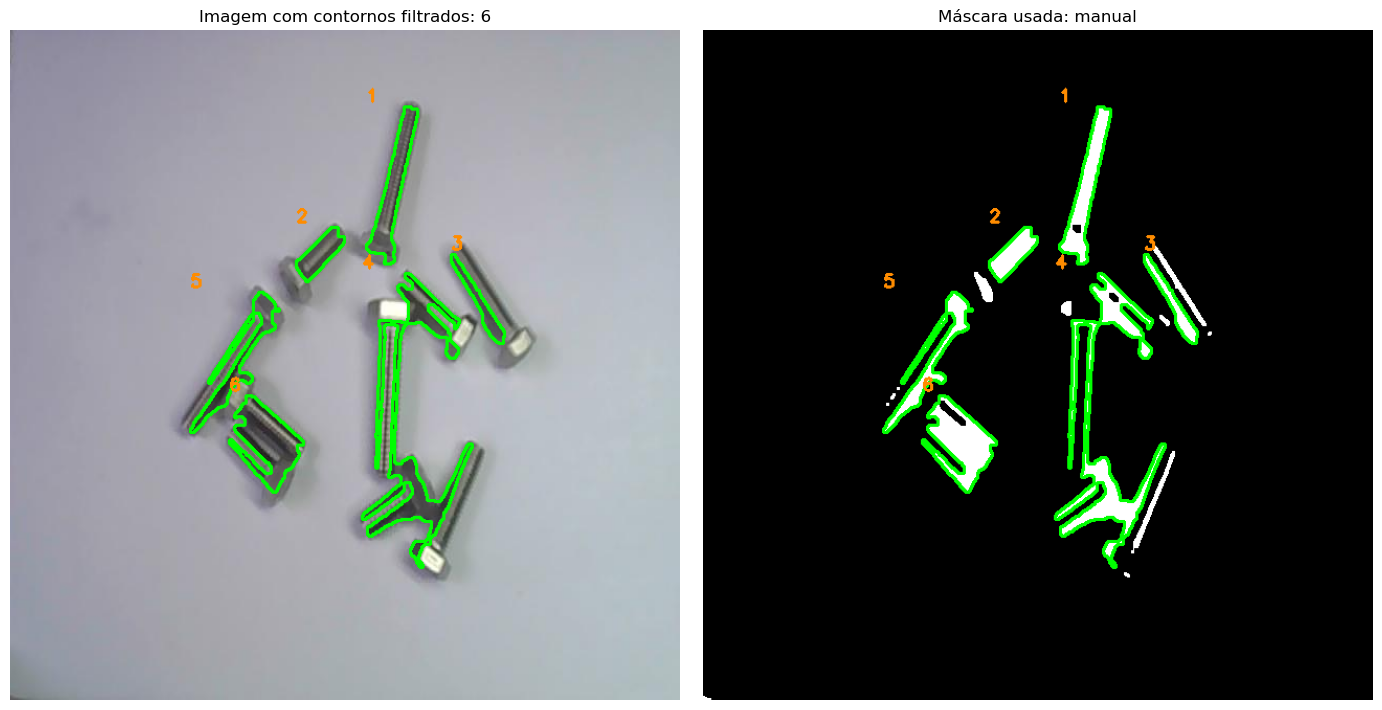

In [98]:
# Visualizar os contornos reais dos candidatos filtrados.
# Esta célula usa as variáveis da célula anterior: selected_mask e candidates.

all_contours, _ = cv2.findContours(selected_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Monta um conjunto com as caixas dos candidatos aprovados.
# Assim conseguimos separar, entre todos os contornos da máscara, somente os que passaram nos filtros.
candidate_boxes = {
    (item['x'], item['y'], item['w'], item['h'])
    for item in candidates
}

valid_contours = []
for contour in all_contours:
    x, y, w, h = cv2.boundingRect(contour)
    if (x, y, w, h) in candidate_boxes:
        valid_contours.append(contour)

# Ordena os contornos na mesma lógica da contagem: de cima para baixo, esquerda para direita.
valid_contours = sorted(valid_contours, key=lambda cnt: (cv2.boundingRect(cnt)[1], cv2.boundingRect(cnt)[0]))

contour_view = image_rgb.copy()
mask_view = cv2.cvtColor(selected_mask, cv2.COLOR_GRAY2RGB)

# Desenha o contorno real, não apenas a caixa retangular.
cv2.drawContours(contour_view, valid_contours, -1, (0, 255, 0), 2)
cv2.drawContours(mask_view, valid_contours, -1, (0, 255, 0), 2)

# Numera cada contorno para comparar com a lista impressa na célula anterior.
for i, contour in enumerate(valid_contours, start=1):
    x, y, w, h = cv2.boundingRect(contour)
    cv2.putText(contour_view, str(i), (x, max(y - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 140, 0), 2)
    cv2.putText(mask_view, str(i), (x, max(y - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 140, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(contour_view)
axes[0].set_title(f'Imagem com contornos filtrados: {len(valid_contours)}')
axes[0].axis('off')

axes[1].imshow(mask_view)
axes[1].set_title(f'Máscara usada: {mask_name}')
axes[1].axis('off')

plt.tight_layout();

## 9. Visualização dos candidatos

Esta célula desenha as caixas encontradas. Quando uma caixa pega só a cabeça ou só o corpo do parafuso, significa que a máscara separou o objeto em partes. Isso explica por que às vezes o algoritmo conta dois onde visualmente há um parafuso.

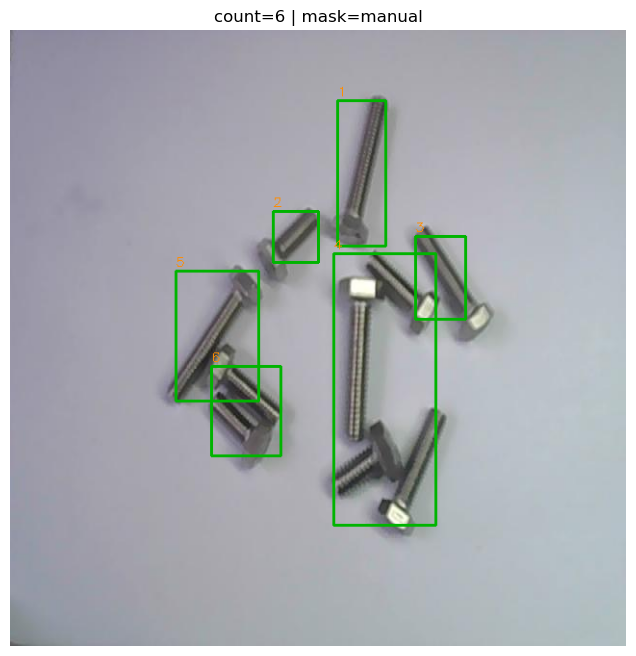

In [99]:
annotated = image_rgb.copy()
for i, item in enumerate(candidates, start=1):
    x, y, w, h = item['x'], item['y'], item['w'], item['h']
    cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 180, 0), 2)
    cv2.putText(annotated, str(i), (x, max(y - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 140, 0), 1)

plt.figure(figsize=(8, 8))
plt.imshow(annotated)
plt.title(f'count={len(candidates)} | mask={mask_name}')
plt.axis('off');

## 10. Escolha automática da melhor máscara

O script não escolhe uma máscara fixa. Ele calcula candidatos em cada máscara e dá uma pontuação. A pontuação considera:

- quantidade de candidatos;
- proximidade da área mediana com a área esperada;
- variação das áreas;
- penalidade para muitos componentes pequenos.

A célula abaixo reproduz essa ideia para comparar as máscaras.

In [100]:
expected_area = 1600
max_reasonable_candidates = 20

all_masks = dict(cleaned_masks)
all_masks['manual'] = manual_mask

scores = []
for name, mask in all_masks.items():
    current = find_candidates(mask, min_area, max_area, max_aspect_ratio, min_circularity, corner_margin)
    if not current:
        score = float('-inf')
        median_area = 0
        area_cv = 0
    else:
        areas = np.array([item['area'] for item in current], dtype=float)
        median_area = float(np.median(areas))
        mean_area = float(np.mean(areas))
        area_cv = float(np.std(areas) / max(mean_area, 1.0))
        area_penalty = abs(median_area - expected_area) / max(expected_area, 1)
        small_component_penalty = max(0.0, (expected_area * 0.35 - median_area) / expected_area)
        noise_penalty = max(0, len(current) - max_reasonable_candidates) * 0.35
        score = (
            len(current) * 0.15
            - min(area_penalty, 6.0)
            - min(area_cv, 3.0) * 0.35
            - small_component_penalty * 3.0
            - noise_penalty
        )

    scores.append((score, name, len(current), median_area, area_cv))

for score, name, count, median_area, area_cv in sorted(scores, reverse=True):
    print(f'{name:10s} score={score:7.3f} count={count:2d} median_area={median_area:8.1f} area_cv={area_cv:5.2f}')

edges      score=  0.468 count= 8 median_area=  2556.2 area_cv= 0.38
manual     score=  0.379 count= 6 median_area=  2077.8 area_cv= 0.64
adaptive   score= -3.581 count= 2 median_area=  7686.2 area_cv= 0.22
otsu_dark  score= -5.703 count= 2 median_area= 15628.0 area_cv= 0.01
otsu_light score=   -inf count= 0 median_area=     0.0 area_cv= 0.00


## 11. Usando diretamente o script oficial

Depois de entender as etapas, você pode chamar as funções do próprio `solucao_1_opencv_morfologia.py`. Isso garante que o notebook e o app estejam comparando com a mesma lógica oficial.

In [101]:
from solucao_1_opencv_morfologia import parse_args, pick_best_mask

args = parse_args([
    '--min-area', str(min_area),
    '--max-area', str(max_area),
    '--expected-area', str(expected_area),
    '--corner-margin', str(corner_margin),
    '--mask-mode', 'auto',
])

best_name, best_mask, best_candidates = pick_best_mask(cv2, np, image_bgr, args)

print('Melhor máscara:', best_name)
print('Contagem:', len(best_candidates))
print('Áreas:', [round(item.area, 1) for item in best_candidates])

Melhor máscara: edges
Contagem: 8
Áreas: [1270.5, 1528.5, 4143.0, 3016.0, 2859.5, 2508.0, 2604.5, 1344.0]


### 11.1 Teste rápido com todos os parâmetros do script

Use esta célula como painel rápido de teste. Ela chama as funções oficiais do script com todos os parâmetros principais e já mostra a imagem anotada.

Troque os valores abaixo e execute a célula novamente.

Imagem: img5.jpg
Modo: manual
Máscara escolhida: limiar_manual_t85
Contagem: 6
Áreas: [2318.5, 1056.5, 813.0, 5406.0, 1837.0, 3056.0]


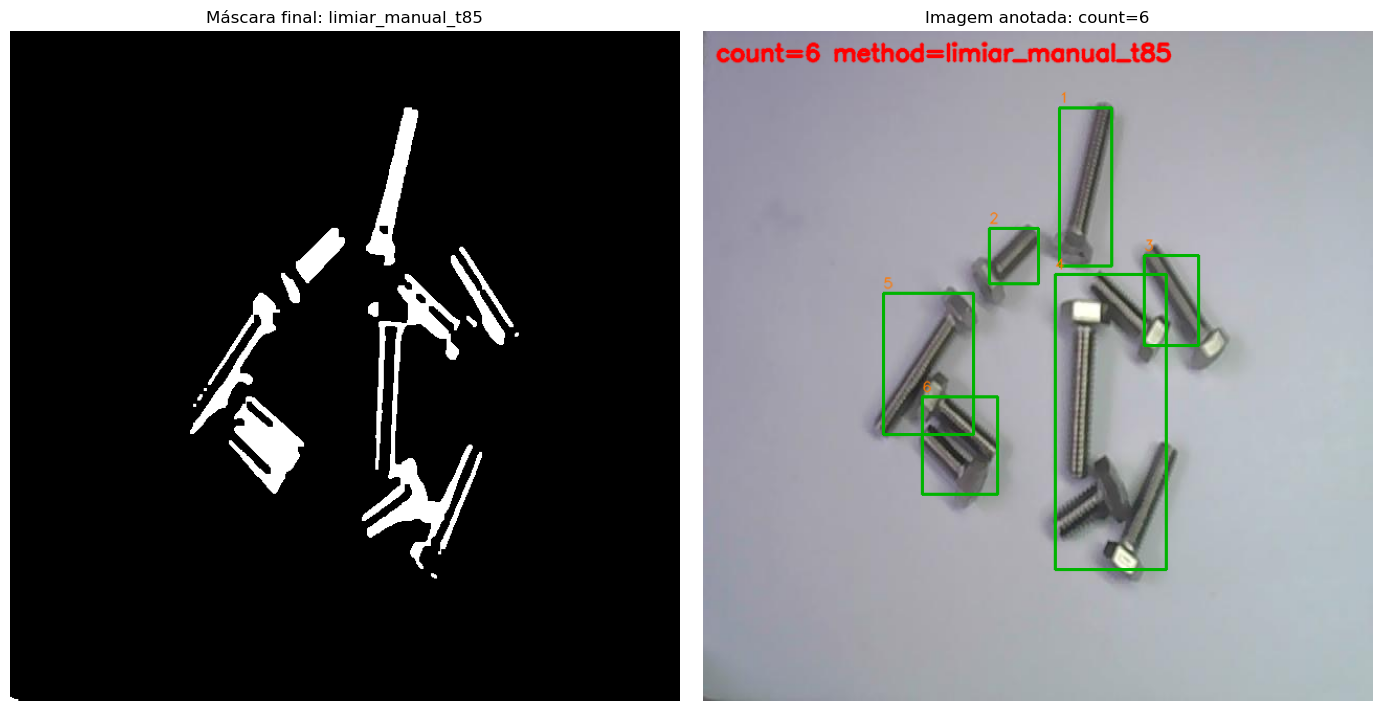

In [102]:
from solucao_1_opencv_morfologia import annotate, parse_args, pick_best_mask

# Escolha dos parâmetros principais do script.
# Use mask_mode = 'auto' para seleção automática ou 'manual' para limiar manual.
script_params = {
    'min_area': 500,
    'max_area': 17500,
    'expected_area': 2000,
    'max_reasonable_candidates': 20,
    'max_aspect_ratio': 8.0,
    'min_circularity': 0.02,
    'corner_margin': 9,
    'mask_mode': 'manual',
    'manual_threshold': 85,
    'manual_blur': 'median',  # 'median' ou 'gauss'
}

args = parse_args([
    '--min-area', str(script_params['min_area']),
    '--max-area', str(script_params['max_area']),
    '--expected-area', str(script_params['expected_area']),
    '--max-reasonable-candidates', str(script_params['max_reasonable_candidates']),
    '--max-aspect-ratio', str(script_params['max_aspect_ratio']),
    '--min-circularity', str(script_params['min_circularity']),
    '--corner-margin', str(script_params['corner_margin']),
    '--mask-mode', script_params['mask_mode'],
    '--manual-threshold', str(script_params['manual_threshold']),
    '--manual-blur', script_params['manual_blur'],
])

best_name, best_mask, best_candidates = pick_best_mask(cv2, np, image_bgr, args)
annotated_bgr = annotate(cv2, image_bgr, best_candidates, best_name)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

print('Imagem:', image_path.name)
print('Modo:', script_params['mask_mode'])
print('Máscara escolhida:', best_name)
print('Contagem:', len(best_candidates))
print('Áreas:', [round(item.area, 1) for item in best_candidates])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(best_mask, cmap='gray')
axes[0].set_title(f'Máscara final: {best_name}')
axes[0].axis('off')

axes[1].imshow(annotated_rgb)
axes[1].set_title(f'Imagem anotada: count={len(best_candidates)}')
axes[1].axis('off')

plt.tight_layout();

### 11.2 Busca automática de parâmetros

Esta célula faz uma varredura em várias combinações de parâmetros do script e ajuda a encontrar configurações que chegam perto da contagem desejada.

Use principalmente na imagem mais difícil: ajuste `target_count`, edite as listas em `search_space` e execute. O resultado mostra as melhores combinações e as imagens anotadas para comparação visual.

Imagem: img5.jpg
Combinações testadas: 2520
Contagem alvo: 8
Combinações que acertaram a contagem: 576
Distribuição das contagens mais comuns: [(6, 648), (8, 576), (7, 432), (9, 216), (10, 216), (4, 144), (13, 144), (5, 72), (11, 72)]

#1 count=8 mask=limiar_manual_t65 área_mediana=644.0 variação=0.49
{'min_area': 310, 'max_area': 11500, 'expected_area': 900, 'corner_margin': 3, 'manual_threshold': 65, 'max_aspect_ratio': 8.0, 'min_circularity': 0.01}

#2 count=8 mask=limiar_manual_t65 área_mediana=644.0 variação=0.49
{'min_area': 310, 'max_area': 11500, 'expected_area': 900, 'corner_margin': 3, 'manual_threshold': 65, 'max_aspect_ratio': 8.0, 'min_circularity': 0.02}

#3 count=8 mask=limiar_manual_t65 área_mediana=644.0 variação=0.49
{'min_area': 310, 'max_area': 11500, 'expected_area': 900, 'corner_margin': 4, 'manual_threshold': 65, 'max_aspect_ratio': 8.0, 'min_circularity': 0.01}

#4 count=8 mask=limiar_manual_t65 área_mediana=644.0 variação=0.49
{'min_area': 310, 'max_area': 1150

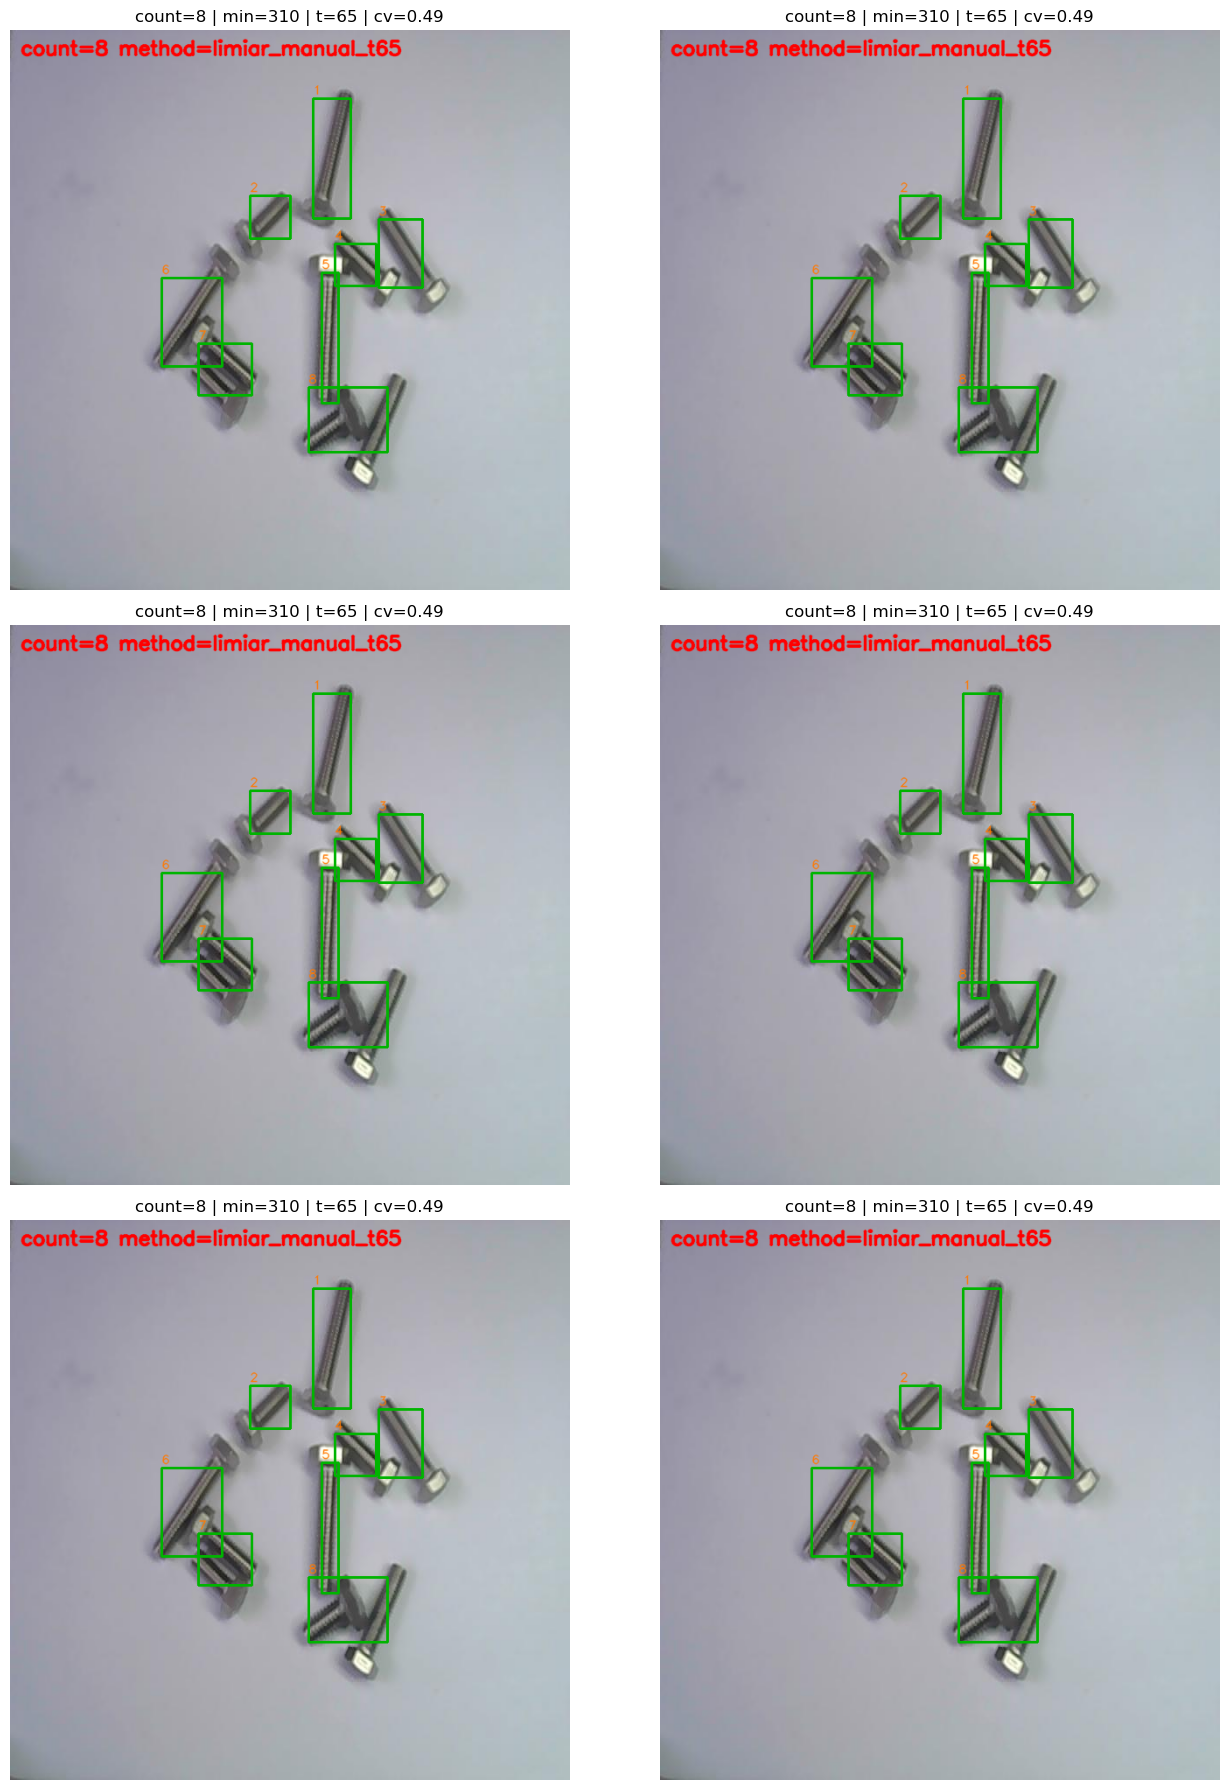

In [104]:
from collections import Counter
from itertools import product

from solucao_1_opencv_morfologia import annotate, parse_args, pick_best_mask

# Contagem esperada para a imagem atual. Troque se estiver testando outra imagem.
target_count = 8

# Quantas melhores combinações mostrar como imagem anotada.
top_n = 6

# Espaço de busca. Comece com poucas opções; aumente depois se precisar refinar.
# Para a imagem difícil, os valores abaixo exploram principalmente o limiar manual.
search_space = {
    'min_area': [170, 240, 310, 380, 500],
    'max_area': [11500, 15000, 17500],
    'expected_area': [900, 1300, 2000],
    'corner_margin': [3, 4, 6, 9],
    'manual_threshold': [55, 60, 65, 70, 75, 80, 85],
    'max_aspect_ratio': [8.0],
    'min_circularity': [0.01, 0.02],
}

fixed_params = {
    'max_reasonable_candidates': 20,
    'mask_mode': 'manual',
    'manual_blur': 'median',
}


def build_args(params):
    """Converte um dicionário de parâmetros no mesmo formato usado pelo script."""
    merged = {**fixed_params, **params}
    return parse_args([
        '--min-area', str(merged['min_area']),
        '--max-area', str(merged['max_area']),
        '--expected-area', str(merged['expected_area']),
        '--max-reasonable-candidates', str(merged['max_reasonable_candidates']),
        '--max-aspect-ratio', str(merged['max_aspect_ratio']),
        '--min-circularity', str(merged['min_circularity']),
        '--corner-margin', str(merged['corner_margin']),
        '--mask-mode', merged['mask_mode'],
        '--manual-threshold', str(merged['manual_threshold']),
        '--manual-blur', merged['manual_blur'],
    ])


keys = list(search_space.keys())
results = []

for values in product(*(search_space[key] for key in keys)):
    params = dict(zip(keys, values))
    args = build_args(params)
    mask_name, mask, candidates = pick_best_mask(cv2, np, image_bgr, args)
    count = len(candidates)
    areas = np.array([candidate.area for candidate in candidates], dtype=float)

    mean_area = float(np.mean(areas)) if len(areas) else 0.0
    median_area = float(np.median(areas)) if len(areas) else 0.0
    area_cv = float(np.std(areas) / max(mean_area, 1.0)) if len(areas) else 999.0

    # Critério de ordenação: primeiro acerta a contagem, depois prefere áreas mais estáveis.
    ranking_score = (
        abs(count - target_count),
        area_cv,
        abs(median_area - params['expected_area']) / max(params['expected_area'], 1),
    )

    results.append({
        'score': ranking_score,
        'count': count,
        'mask_name': mask_name,
        'mean_area': mean_area,
        'median_area': median_area,
        'area_cv': area_cv,
        'params': params,
    })

results = sorted(results, key=lambda item: item['score'])
matches = [item for item in results if item['count'] == target_count]
selected = (matches if matches else results)[:top_n]

print('Imagem:', image_path.name)
print('Combinações testadas:', len(results))
print('Contagem alvo:', target_count)
print('Combinações que acertaram a contagem:', len(matches))
print('Distribuição das contagens mais comuns:', Counter(item['count'] for item in results).most_common(10))
print()

for index, item in enumerate(selected, start=1):
    print(f"#{index} count={item['count']} mask={item['mask_name']} "
          f"área_mediana={item['median_area']:.1f} variação={item['area_cv']:.2f}")
    print(item['params'])
    print()

cols = 2
rows = int(np.ceil(len(selected) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows))
axes = np.array(axes).reshape(-1)

for axis, item in zip(axes, selected):
    args = build_args(item['params'])
    mask_name, mask, candidates = pick_best_mask(cv2, np, image_bgr, args)
    annotated_bgr = annotate(cv2, image_bgr, candidates, mask_name)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    axis.imshow(annotated_rgb)
    axis.set_title(
        f"count={len(candidates)} | min={item['params']['min_area']} | "
        f"t={item['params']['manual_threshold']} | cv={item['area_cv']:.2f}"
    )
    axis.axis('off')

for axis in axes[len(selected):]:
    axis.axis('off')

plt.tight_layout();


## 12. Dicas de interpretação

- Se aparecem muitos quadrados pequenos, aumente `min_area`.
- Se um parafuso inteiro desaparece, aumente `max_area` ou reduza `min_area`.
- Se a borda da imagem é contada como objeto, aumente `corner_margin`.
- Se cabeça e corpo viram dois objetos, tente outro `mask_name` ou use o campo **Correção** no Dash.
- Para imagens com fundo claro, teste `mask_name = 'manual'` e ajuste `manual_threshold`.

A principal conclusão é que OpenCV é explicável e leve, mas depende de calibração. Por isso o Dash mostra `Automática`, `Correção` e `Final`.